# Carga de datos de precipitación sub-horaria

Esta notebook construye el conjunto de etiquetas de ground truth para el modelo de nowcasting. A partir de los registros de precipitación sub-horaria descargados de [`s54a-sgyg`](https://www.datos.gov.co/Ambiente-y-Desarrollo-Sostenible/Precipitaci-n/s54a-sgyg/about_data) para las 70 estaciones seleccionadas en 2024 y 2025, se agregan los datos a resolución horaria, se define el umbral 
operativo de lluvia fuerte, y se etiqueta cada hora como evento de lluvia fuerte (1) o no (0).

Los archivos CSV por estación se encuentran en `data/rainfall_subhourly/`, con tres columnas: `codigoestacion`, `fechaobservacion` y `valorobservado` (mm).

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import time
from datetime import datetime

## 1. Descarga

Los datos se descargan del dataset `s54a-sgyg` para las 70 estaciones seleccionadas en 2024 y 2025. El script descarga mes a mes por estación, guarda un log de combinaciones completadas para reanudar si se interrumpe, y almacena un CSV por estación en `data/rainfall_subhourly/`.

**Nota:** si los CSVs ya existen en `data/rainfall_subhourly/`, esta sección no necesita correrse de nuevo. Pasar directamente a la sección 2.

In [ ]:
# Configuración
URL_PRECIP = "https://www.datos.gov.co/resource/s54a-sgyg.json"
AÑOS = [2024, 2025]
MESES = range(1, 13)
PAUSA = 0.5  # segundos entre consultas
REINTENTOS = 3
LOG_FILE = "descarga_precipitacion_log.txt"
OUTPUT_DIR = r"..\..\data\rainfall_subhourly"

# Crear carpeta de salida
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Cargar log de combinaciones ya completadas
completados = set()
if os.path.exists(LOG_FILE):
    with open(LOG_FILE, 'r') as f:
        completados = set(line.strip() for line in f.readlines())
print(f"Combinaciones ya completadas: {len(completados)}")

# Cargar estaciones objetivo
df_anual = pd.read_csv('precipitacion_anual_candidatas.csv', dtype={'codigoestacion': str})
est_2024 = set(df_anual[df_anual['anio'] == 2024]['codigoestacion'])
est_2025 = set(df_anual[df_anual['anio'] == 2025]['codigoestacion'])
estaciones_objetivo = est_2024 | est_2025
print(f"Estaciones objetivo: {len(estaciones_objetivo)}")

# Función de descarga con reintentos
def descargar_mes(cod, año, mes):
    fecha_ini = f"{año}-{mes:02d}-01T00:00:00"
    if mes == 12:
        fecha_fin = f"{año}-12-31T23:59:59"
    else:
        fecha_fin = f"{año}-{mes+1:02d}-01T00:00:00"
    
    for intento in range(REINTENTOS):
        try:
            params = {
                "$where": f"codigoestacion='{cod}' AND fechaobservacion >= '{fecha_ini}' AND fechaobservacion < '{fecha_fin}'",
                "$order": "fechaobservacion ASC",
                "$limit": 50000
            }
            r = requests.get(URL_PRECIP, params=params, timeout=60)
            data = r.json()
            if isinstance(data, list):
                return data
        except Exception as e:
            print(f"  Intento {intento+1}/{REINTENTOS} fallido: {e}")
            time.sleep(2 ** intento)  # espera exponencial: 1, 2, 4 segundos
    return None

# Descarga principal
total = len(estaciones_objetivo) * len(AÑOS) * len(list(MESES))
procesados = 0

for cod in sorted(estaciones_objetivo):
    registros_estacion = []
    
    for año in AÑOS:
        # Solo descargar si la estación tiene datos ese año
        if año == 2024 and cod not in est_2024:
            continue
        if año == 2025 and cod not in est_2025:
            continue
        
        for mes in MESES:
            key = f"{cod}_{año}_{mes:02d}"
            procesados += 1
            
            if key in completados:
                print(f"[{procesados}/{total}] Ya completado: {key}")
                continue
            
            print(f"[{procesados}/{total}] Descargando: {key}...")
            data = descargar_mes(cod, año, mes)
            
            if data is None:
                print(f"  ERROR: no se pudo descargar {key} después de {REINTENTOS} intentos")
                continue
            
            if len(data) > 0:
                registros_estacion.extend(data)
                print(f"  OK: {len(data)} registros")
            else:
                print(f"  Sin datos")
            
            # Registrar en log
            with open(LOG_FILE, 'a') as f:
                f.write(key + '\n')
            
            time.sleep(PAUSA)
    
    # Guardar CSV por estación
    if registros_estacion:
        df_est = pd.DataFrame(registros_estacion)
        df_est = df_est[['codigoestacion', 'fechaobservacion', 'valorobservado']]
        df_est.to_csv(f"{OUTPUT_DIR}/{cod}.csv", index=False)
        print(f"  Guardado: {OUTPUT_DIR}/{cod}.csv ({len(df_est)} registros)")

print("\nDescarga completada.")

Combinaciones ya completadas: 0
Estaciones objetivo: 70
[1/1680] Descargando: 0021201980_2024_01...
  OK: 5922 registros
[2/1680] Descargando: 0021201980_2024_02...
  OK: 6879 registros
[3/1680] Descargando: 0021201980_2024_03...
  OK: 5742 registros
[4/1680] Descargando: 0021201980_2024_04...
  OK: 206 registros
[5/1680] Descargando: 0021201980_2024_05...
  OK: 103 registros
[6/1680] Descargando: 0021201980_2024_06...
  Sin datos
[7/1680] Descargando: 0021201980_2024_07...
  Sin datos
[8/1680] Descargando: 0021201980_2024_08...
  Sin datos
[9/1680] Descargando: 0021201980_2024_09...
  OK: 998 registros
[10/1680] Descargando: 0021201980_2024_10...
  OK: 23475 registros
[11/1680] Descargando: 0021201980_2024_11...
  OK: 38974 registros
[12/1680] Descargando: 0021201980_2024_12...
  OK: 46428 registros
[13/1680] Descargando: 0021201980_2025_01...
  OK: 50000 registros
[14/1680] Descargando: 0021201980_2025_02...
  OK: 10034 registros
[15/1680] Descargando: 0021201980_2025_03...
  OK: 111

### 1.1 Verificación de la descarga

Como verificación de la descarga, se examinan los registros de la estación `0021201980 (Cerro Guadalupe)`, que sirve de referencia por haber sido validada previamente contra la visualización oficial del portal datos.gov.co.

La precipitación total anual es similar en ambos años (~564 mm en 2024 y ~552 mm en 2025), consistente con los totales reportados por la fuente original. La serie diaria muestra el patrón climatológico esperado para la Sabana de Bogotá: temporada seca en el primer semestre de 2024 (enero-agosto, coincidente con el final del episodio El Niño), un pico de actividad convectiva en el último trimestre de 2024 con un evento extremo de ~170 mm el 4 de noviembre, y una distribución más uniforme a lo largo de 2025. La descarga se considera verificada.

   anio  valorobservado
0  2024           564.1
1  2025           552.8


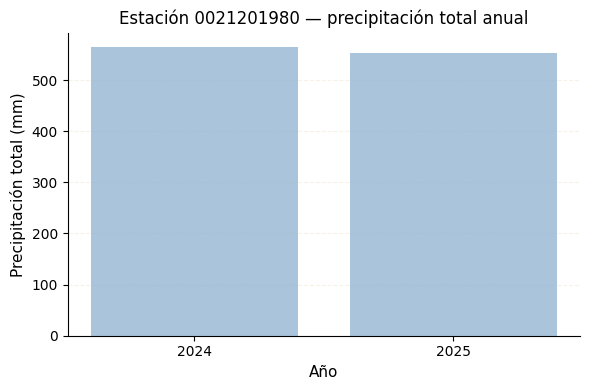

In [33]:
df_test = pd.read_csv(r'..\..\data\rainfall_subhourly\0021201980.csv')  #  
df_test['fechaobservacion'] = pd.to_datetime(df_test['fechaobservacion'])
df_test['anio'] = df_test['fechaobservacion'].dt.year
df_test['valorobservado'] = pd.to_numeric(df_test['valorobservado'])

precip_anual = df_test.groupby('anio')['valorobservado'].sum().reset_index()
print(precip_anual)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(precip_anual['anio'], precip_anual['valorobservado'], color='#94B6D2', alpha=0.8)
ax.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
ax.set_axisbelow(True)
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Precipitación total (mm)', fontsize=11)
ax.set_title('Estación 0021201980 — precipitación total anual', fontsize=12)
ax.set_xticks([2024, 2025])
plt.tight_layout()
plt.show()

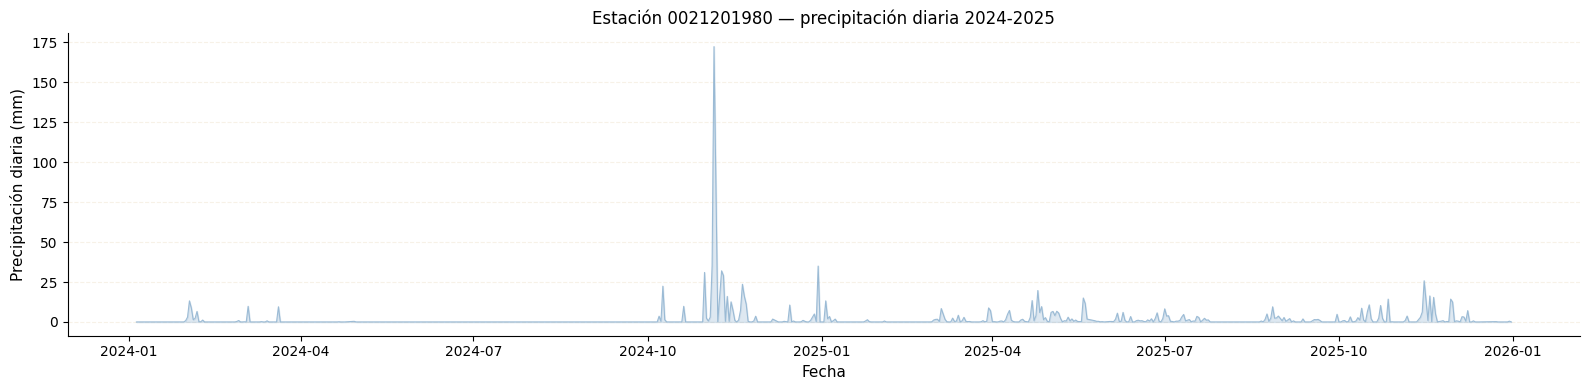

In [34]:
precip_diaria = df_test.groupby(df_test['fechaobservacion'].dt.date)['valorobservado'].sum().reset_index()
precip_diaria.columns = ['fecha', 'precip_mm']
precip_diaria['fecha'] = pd.to_datetime(precip_diaria['fecha'])

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(precip_diaria['fecha'], precip_diaria['precip_mm'], 
        color='#94B6D2', linewidth=0.8, alpha=0.9)
ax.fill_between(precip_diaria['fecha'], precip_diaria['precip_mm'], 
                alpha=0.3, color='#94B6D2')
ax.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
ax.set_axisbelow(True)
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Precipitación diaria (mm)', fontsize=11)
ax.set_title('Estación 0021201980 — precipitación diaria 2024-2025', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Selección y control de calidad de estaciones

De las 70 estaciones descargadas, no todas tienen cobertura temporal suficiente para ser útiles en el entrenamiento y validación del modelo. Se aplica un control de calidad en dos pasos: primero, se evalúa la cobertura temporal de cada estación medida como el rango entre el primer y el último registro disponible; segundo, se evalúa la densidad de registros en ese período para detectar estaciones con transmisión irregular o gaps significativos.

In [2]:
# Ver tamaño de cada CSV
resumen_csvs = []
for archivo in sorted(os.listdir(r'..\..\data\rainfall_subhourly')):
    if archivo.endswith('.csv'):
        df = pd.read_csv(r'..\..\data\rainfall_subhourly\\' + archivo, 
                         dtype={'codigoestacion': str})
        resumen_csvs.append({
            'estacion': archivo.replace('.csv', ''),
            'n_registros': len(df),
            'fecha_min': df['fechaobservacion'].min(),
            'fecha_max': df['fechaobservacion'].max()
        })

df_resumen = pd.DataFrame(resumen_csvs)
print(df_resumen.sort_values('n_registros').to_string())

      estacion  n_registros                fecha_min                fecha_max
20  0021206990          268  2024-09-04T00:00:00.000  2024-09-13T03:30:00.000
19  0021206980        31417  2025-05-16T00:00:00.000  2025-12-31T23:50:00.000
9   0021205700        39509  2024-10-29T02:10:00.000  2025-12-31T23:50:00.000
22  0035025060        53941  2024-10-29T02:10:00.000  2025-12-31T23:50:00.000
8   0021205420        64725  2024-10-29T03:00:00.000  2025-12-31T23:50:00.000
13  0021206280        66809  2024-09-04T00:00:00.000  2025-12-31T23:50:00.000
69  2306500204        67838  2024-10-29T02:10:00.000  2025-12-31T23:50:00.000
12  0021205910        68458  2024-09-04T00:00:00.000  2025-12-31T23:50:00.000
64  2120500135        69048  2024-09-04T00:20:00.000  2025-12-31T23:50:00.000
7   0021205012        69086  2024-09-04T00:00:00.000  2025-12-31T23:50:00.000
14  0021206560        69205  2024-07-07T00:00:00.000  2025-12-31T23:50:00.000
10  0021205710        69238  2024-09-04T00:00:00.000  2025-12-31

### 2.1 Cobertura temporal

El análisis revela dos grupos claramente diferenciados. Un primer grupo de 53 estaciones tiene cobertura de al menos 23 meses (enero 2024 a diciembre 2025), con conteos superiores a 350,000 registros. Un segundo grupo de 17 estaciones tiene cobertura parcial, con inicio entre abril de 2024 y octubre de 2025, y finalización en su mayoría en diciembre de 2025.

Dentro del grupo de cobertura parcial se aplican los siguientes criterios de exclusión:

- **Cobertura inferior a 6 meses o densidad de registros insuficiente:** se excluyen las estaciones `0021206990` (268 registros, 10 días en septiembre 2024), `2120000104` (71,486 registros, octubre-diciembre 2025) y `0021206980` (31,417 registros, mayo-diciembre 2025). Las dos primeras no capturan ningún ciclo estacional completo; la tercera, aunque tiene 7 meses de datos, presenta una densidad de registros inferior a la mitad de lo esperado para ese período, lo que indica gaps significativos en la transmisión.

- **Cobertura entre 12 y 22 meses:** las 14 estaciones restantes serán evaluadas en la siguiente sección mediante su densidad de registros. Si la densidad es suficiente, se conservan como candidatas al conjunto de prueba, dado que su inicio tardío en 2024 limita su utilidad para el entrenamiento pero no para la evaluación.

Estaciones con cobertura parcial (<23 meses): 17


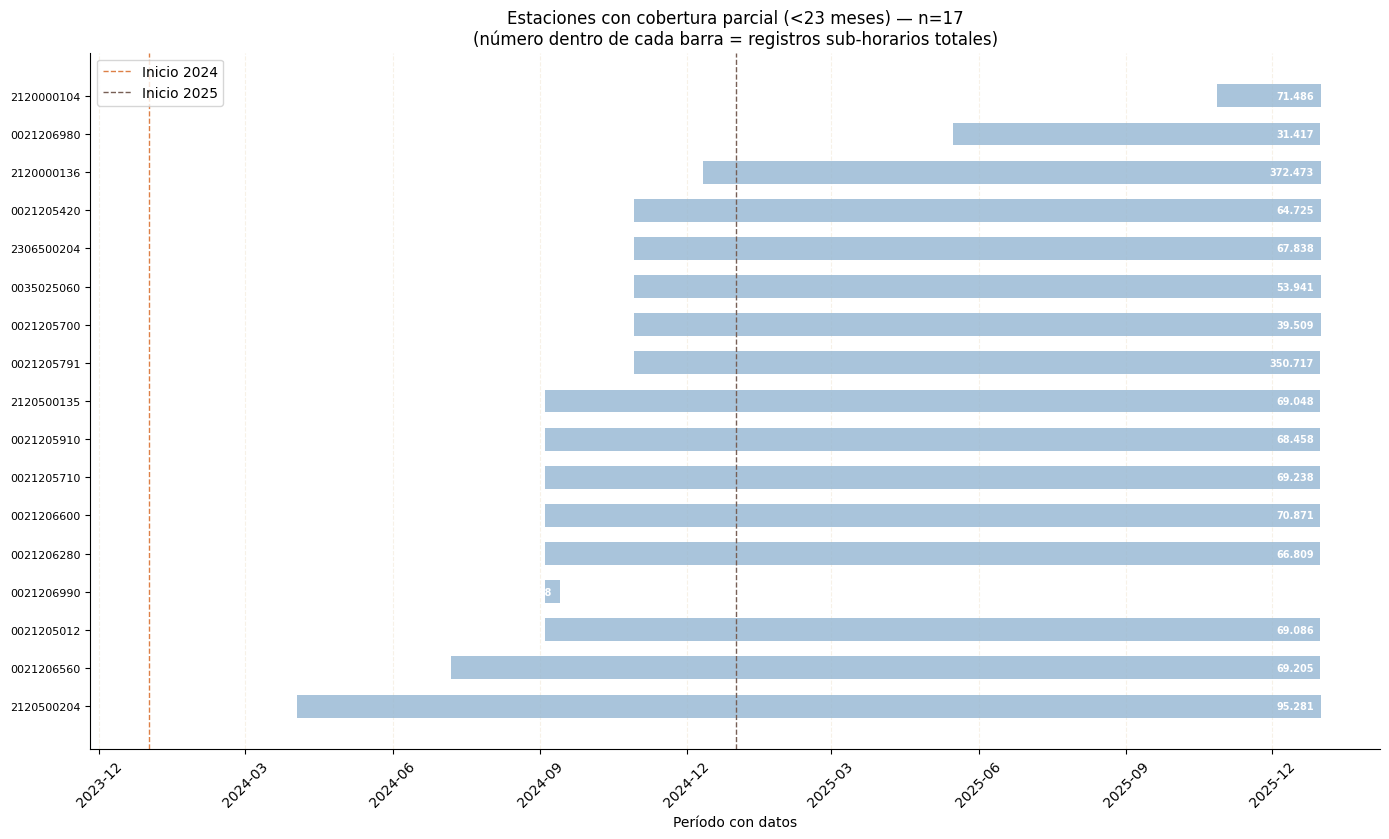

In [6]:
df_resumen['fecha_min'] = pd.to_datetime(df_resumen['fecha_min'])
df_resumen['fecha_max'] = pd.to_datetime(df_resumen['fecha_max'])
df_resumen['duracion_meses'] = ((df_resumen['fecha_max'] - df_resumen['fecha_min']).dt.days / 30.44).round(1)

# Solo estaciones con menos de 24 meses
df_plot_parcial = df_resumen[df_resumen['duracion_meses'] < 23].sort_values('fecha_min').reset_index(drop=True)
print(f"Estaciones con cobertura parcial (<23 meses): {len(df_plot_parcial)}")

fig, ax = plt.subplots(figsize=(14, max(6, len(df_plot_parcial) * 0.5)))

for i, row in df_plot_parcial.iterrows():
    duracion = (row['fecha_max'] - row['fecha_min']).days
    ax.barh(i, duracion, left=row['fecha_min'], height=0.6,
            color='#94B6D2', alpha=0.8)
    
    ax.text(row['fecha_max'] - pd.Timedelta(days=5), i,
            f"{row['n_registros']:,}".replace(',', '.'),
            va='center', ha='right', fontsize=7, color='white',
            fontweight='bold')

ax.axvline(pd.Timestamp('2024-01-01'), color='#DD8047', linestyle='--', linewidth=1, label='Inicio 2024')
ax.axvline(pd.Timestamp('2025-01-01'), color='#775F55', linestyle='--', linewidth=1, label='Inicio 2025')

ax.set_yticks(range(len(df_plot_parcial)))
ax.set_yticklabels(df_plot_parcial['estacion'], fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.set_xlabel('Período con datos')
ax.set_title(f'Estaciones con cobertura parcial (<23 meses) — n={len(df_plot_parcial)}\n(número dentro de cada barra = registros sub-horarios totales)',
             fontsize=12)
ax.legend()
ax.yaxis.grid(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 2.2 Densidad de registros

La cobertura temporal no es suficiente por sí sola para garantizar la calidad de una estación: una estación puede tener un rango temporal amplio pero con gaps internos que reduzcan significativamente la información disponible. Para las 14 estaciones con cobertura parcial que superaron el filtro anterior, se calcula la densidad de registros que se define como el cociente entre los registros reales y los esperados según la cadencia mediana de transmisión de cada estación.

**Densidad por cobertura de referencia:** se compara el número de registros reales contra los esperados si la estación hubiera transmitido con la misma frecuencia mediana que las 53 estaciones con cobertura completa (~731 registros por día). Este primer análisis reveló que 12 de las 14 estaciones tienen densidades entre 12% y 22% — aparentemente muy bajas. Sin embargo, antes de excluirlas, se investigó la cadencia real de transmisión de cada estación.

**Densidad por cadencia real:** la cadencia mediana varía entre estaciones. La mayoría transmite cada 10 minutos, `0021205791` cada 2.2 minutos en promedio, y `2120000136` cada 1.3 minutos. Al recalcular los registros esperados usando la cadencia propia de cada estación, las densidades se reinterpretan completamente: hay 11 estaciones que parecían deficientes tienen en realidad densidades entre 87% y 110%, transmiten correctamente a 10 minutos y no a 2 minutos como la referencia global.

In [25]:
# Estaciones con cobertura parcial (excluidas las 3 ya descartadas)
excluir = ['0021206990', '2120000104', '0021206980']
df_parcial = df_resumen[
    (df_resumen['duracion_meses'] < 23) & 
    (~df_resumen['estacion'].isin(excluir))
].copy()

# Días de cobertura
df_parcial['dias_cobertura'] = (df_parcial['fecha_max'] - df_parcial['fecha_min']).dt.days

# Registros esperados según referencia de estaciones completas
registros_por_dia_referencia = df_resumen[df_resumen['duracion_meses'] >= 23]['n_registros'].median() / (24 * 30.44)
df_parcial['reg_esp_cobertura'] = (df_parcial['dias_cobertura'] * registros_por_dia_referencia).astype(int)
df_parcial['densidad_cobertura_pct'] = (df_parcial['n_registros'] / df_parcial['reg_esp_cobertura'] * 100).round(1)

# Cadencia real por estación
def estadisticas_cadencia(cod):
    try:
        df = pd.read_csv(f'..\\..\\data\\rainfall_subhourly\\{cod}.csv')
        df['fechaobservacion'] = pd.to_datetime(df['fechaobservacion'])
        df = df.sort_values('fechaobservacion')
        intervalos = df['fechaobservacion'].diff().dt.total_seconds() / 60
        intervalos = intervalos[(intervalos > 0) & (intervalos <= 60)]  # excluir outliers
        return intervalos.min(), intervalos.max(), intervalos.mean().round(1)
    except:
        return None, None, None

df_parcial[['cadencia_min', 'cadencia_max', 'cadencia_prom']] = df_parcial['estacion'].apply(
    lambda cod: pd.Series(estadisticas_cadencia(cod))
)

# Registros esperados según cadencia real
df_parcial['reg_esp_cadencia'] = (
    df_parcial['dias_cobertura'] * 24 * 60 / df_parcial['cadencia_prom']
).astype(int)
df_parcial['densidad_cadencia_pct'] = (
    df_parcial['n_registros'] / df_parcial['reg_esp_cadencia'] * 100
).round(1)

# Tabla final
cols = ['estacion', 'duracion_meses', 'n_registros', 
        'reg_esp_cobertura', 'densidad_cobertura_pct',
        'cadencia_min', 'cadencia_max', 'cadencia_prom',
        'reg_esp_cadencia', 'densidad_cadencia_pct']

df_parcial[cols].sort_values('densidad_cadencia_pct')

,estacion,duracion_meses,n_registros,reg_esp_cobertura,densidad_cobertura_pct,cadencia_min,cadencia_max,cadencia_prom,reg_esp_cadencia,densidad_cadencia_pct
9,0021205700,14.1,39509,313161,12.6,10.0,60.0,10.0,61632,64.1
52,2120000136,12.6,372473,281699,132.2,1.0,58.0,1.3,426461,87.3
22,0035025060,14.1,53941,313161,17.2,10.0,60.0,10.0,61632,87.5
14,0021206560,17.8,69205,396574,17.5,10.0,60.0,10.0,78048,88.7
13,0021206280,15.9,66809,353404,18.9,10.0,50.0,10.0,69552,96.1
12,0021205910,15.9,68458,353404,19.4,10.0,40.0,10.0,69552,98.4
7,0021205012,15.9,69086,353404,19.5,10.0,40.0,10.0,69552,99.3
64,2120500135,15.9,69048,353404,19.5,10.0,30.0,10.0,69552,99.3
10,0021205710,15.9,69238,353404,19.6,10.0,40.0,10.0,69552,99.5
15,0021206600,15.9,70871,353404,20.1,1.0,60.0,10.1,68863,102.9


Tras este análisis, solo una estación presenta densidad real problemática:

- **`0021205700` (64.1%):** la inspección visual de sus registros diarios confirma gaps prolongados y sistemáticos (períodos de semanas sin transmisión en enero-febrero 2025 y mayo-julio 2025) que comprometen su utilidad tanto para entrenamiento como para prueba. Se excluye.

- **`2120000136` (87.3%):** aunque tiene la densidad más baja del grupo aceptable, la inspección visual muestra gaps cortos y dispersos, sin ausencias prolongadas. Se conserva.

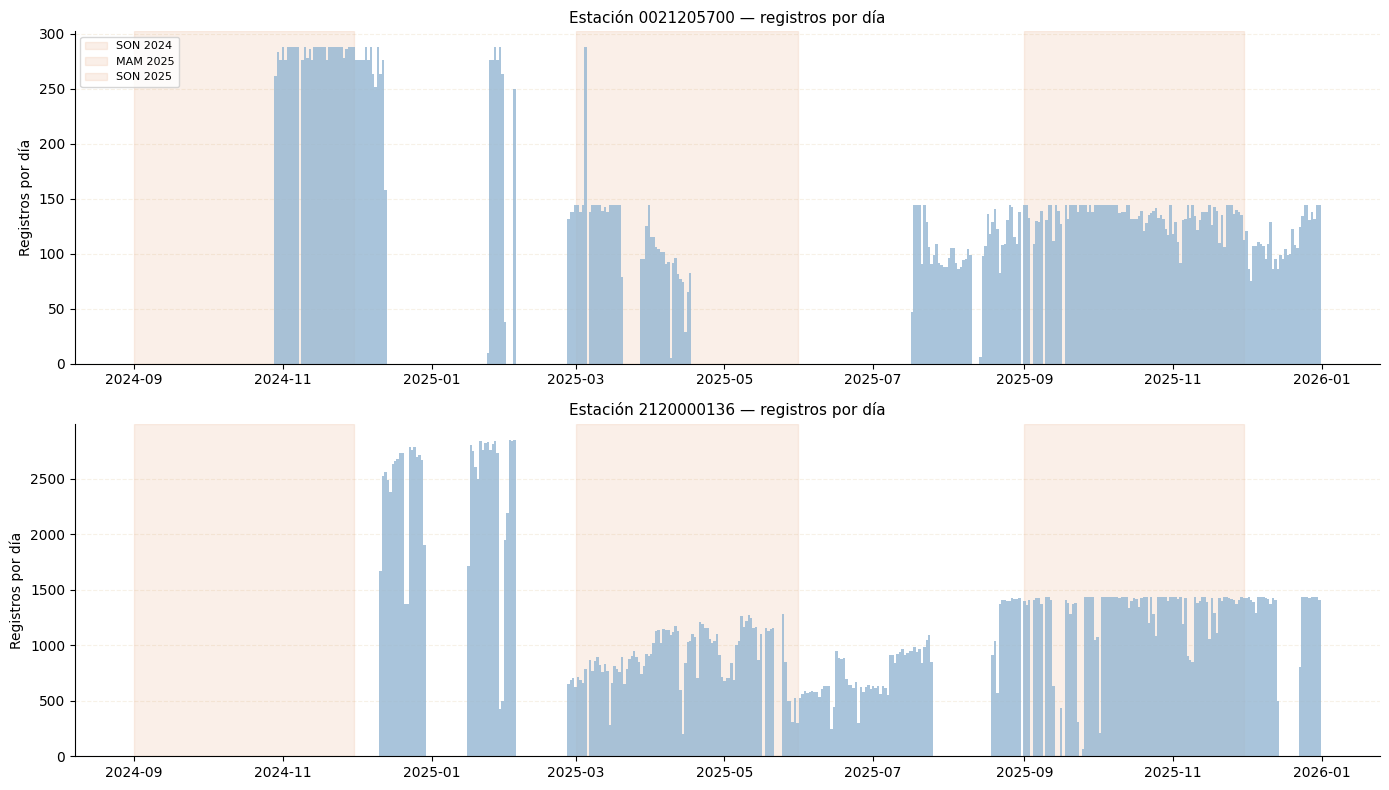

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Definir temporadas MAM y SON para 2024 y 2025
temporadas = [
    (pd.Timestamp('2024-09-01'), pd.Timestamp('2024-11-30'), 'SON 2024'),
    (pd.Timestamp('2025-03-01'), pd.Timestamp('2025-05-31'), 'MAM 2025'),
    (pd.Timestamp('2025-09-01'), pd.Timestamp('2025-11-30'), 'SON 2025'),
]

for ax, cod in zip(axes, ['0021205700', '2120000136']):
    df_est = pd.read_csv(f'..\\..\\data\\rainfall_subhourly\\{cod}.csv')
    df_est['fechaobservacion'] = pd.to_datetime(df_est['fechaobservacion'])
    df_est = df_est.sort_values('fechaobservacion')
    
    df_diario = df_est.groupby(df_est['fechaobservacion'].dt.date).size().reset_index()
    df_diario.columns = ['fecha', 'n_registros']
    df_diario['fecha'] = pd.to_datetime(df_diario['fecha'])
    
    # Sombrear temporadas
    for ini, fin, label in temporadas:
        ax.axvspan(ini, fin, alpha=0.12, color='#DD8047', 
                   label=label if cod == '0021205700' else '')
    
    ax.bar(df_diario['fecha'], df_diario['n_registros'],
           color='#94B6D2', alpha=0.8, width=1)
    ax.set_title(f'Estación {cod} — registros por día', fontsize=11)
    ax.set_ylabel('Registros por día')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
    ax.set_axisbelow(True)

axes[0].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

En total se excluyen **4 estaciones** del dataset final:

| Estación | Motivo de exclusión |
|----------|-------------------|
| `0021206990` | 10 días de datos (268 registros), sin representatividad estacional |
| `2120000104` | 2 meses de datos (oct-dic 2025), fuera del período de entrenamiento |
| `0021206980` | 7 meses con baja densidad de registros (31,417 registros) |
| `0021205700` | Gaps severos y sistemáticos (densidad real 64.1%) |

El dataset final de ground truth queda compuesto por **66 estaciones**.

In [27]:
# Lista final de estaciones excluidas
excluir = ['0021206990', '2120000104', '0021206980', '0021205700']

# Estaciones seleccionadas
estaciones_seleccionadas = df_resumen[
    ~df_resumen['estacion'].isin(excluir)
].copy()

print(f"Estaciones seleccionadas: {len(estaciones_seleccionadas)}")
print(f"Estaciones excluidas: {len(excluir)}")

# Guardar lista de estaciones seleccionadas
estaciones_seleccionadas[['estacion', 'duracion_meses', 'n_registros', 'fecha_min', 'fecha_max']].to_csv(
    'estaciones_ground_truth.csv', index=False
)
print("Guardado: estaciones_ground_truth.csv")

Estaciones seleccionadas: 66
Estaciones excluidas: 4
Guardado: estaciones_ground_truth.csv


## 3. Cómo llueve!

In [28]:
# Cargar lista de estaciones seleccionadas
estaciones_gt = pd.read_csv('estaciones_ground_truth.csv', dtype={'estacion': str})
codigos_gt = set(estaciones_gt['estacion'])
print(f"Estaciones a cargar: {len(codigos_gt)}")

# Cargar y concatenar todos los CSVs
carpeta = r'..\..\data\rainfall_subhourly'
dfs = []

for archivo in os.listdir(carpeta):
    if archivo.endswith('.csv'):
        cod = archivo.replace('.csv', '')
        if cod in codigos_gt:
            df = pd.read_csv(
                os.path.join(carpeta, archivo),
                dtype={'codigoestacion': str}
            )
            dfs.append(df)

df_precip = pd.concat(dfs, ignore_index=True)

# Convertir tipos
df_precip['fechaobservacion'] = pd.to_datetime(df_precip['fechaobservacion'])
df_precip['valorobservado'] = pd.to_numeric(df_precip['valorobservado'], errors='coerce')

print(f"Total registros cargados: {len(df_precip):,}")
print(f"Estaciones únicas: {df_precip['codigoestacion'].nunique()}")
print(f"Rango de fechas: {df_precip['fechaobservacion'].min()} a {df_precip['fechaobservacion'].max()}")

Estaciones a cargar: 66
Total registros cargados: 28,907,285
Estaciones únicas: 66
Rango de fechas: 2024-01-01 09:07:00 a 2025-12-31 23:59:00


In [29]:
# Agregar a horario — sumar mm por estación por hora
df_precip['hora'] = df_precip['fechaobservacion'].dt.floor('h')

df_horario = df_precip.groupby(['codigoestacion', 'hora']).agg(
    precip_mm=('valorobservado', 'sum'),
    n_registros=('valorobservado', 'count')
).reset_index()

print(f"Total filas horarias: {len(df_horario):,}")
print(f"Promedio registros sub-horarios por hora: {df_horario['n_registros'].mean():.1f}")
print(df_horario.head(5))

Total filas horarias: 781,936
Promedio registros sub-horarios por hora: 37.0
  codigoestacion                hora  precip_mm  n_registros
0     0021201980 2024-01-05 13:00:00        0.0           14
1     0021201980 2024-01-05 14:00:00        0.0           17
2     0021201980 2024-01-05 15:00:00        0.0           14
3     0021201980 2024-01-05 16:00:00        0.0           15
4     0021201980 2024-01-05 17:00:00        0.0           17


In [30]:
# Solo horas con lluvia (> 0 mm)
df_lluvia = df_horario[df_horario['precip_mm'] > 0].copy()

print(f"Horas con lluvia: {len(df_lluvia):,} ({len(df_lluvia)/len(df_horario)*100:.1f}% del total)")
print(f"\nDistribución de precipitación horaria (mm/h) — solo horas con lluvia:")
print(df_lluvia['precip_mm'].describe(percentiles=[.5, .75, .90, .95, .99]))

Horas con lluvia: 61,474 (7.9% del total)

Distribución de precipitación horaria (mm/h) — solo horas con lluvia:
count    61474.000000
mean         1.287494
std          3.446821
min          0.001000
50%          0.400000
75%          1.000000
90%          2.800000
95%          5.200000
99%         15.400000
max         94.200000
Name: precip_mm, dtype: float64


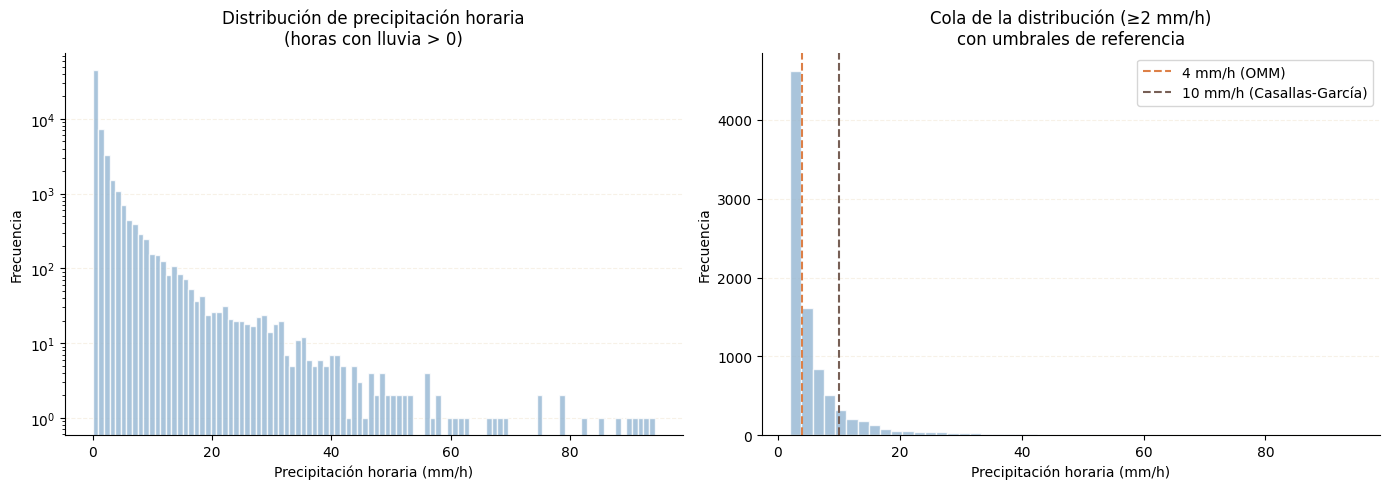

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda — distribución completa en escala log
axes[0].hist(df_lluvia['precip_mm'], bins=100, color='#94B6D2', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Precipitación horaria (mm/h)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de precipitación horaria\n(horas con lluvia > 0)')
axes[0].set_yscale('log')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Derecha — zoom en la cola (> 2 mm/h)
df_cola = df_lluvia[df_lluvia['precip_mm'] >= 2]
axes[1].hist(df_cola['precip_mm'], bins=50, color='#94B6D2', alpha=0.8, edgecolor='white')
for umbral, label, color in [(4, '4 mm/h (OMM)', '#DD8047'), 
                              (10, '10 mm/h (Casallas-García)', '#775F55')]:
    axes[1].axvline(umbral, color=color, linestyle='--', linewidth=1.5, label=label)
axes[1].set_xlabel('Precipitación horaria (mm/h)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Cola de la distribución (≥2 mm/h)\ncon umbrales de referencia')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

for ax in axes:
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [32]:
for umbral in [4, 5, 7, 10]:
    n_positivos = (df_horario['precip_mm'] >= umbral).sum()
    pct = n_positivos / len(df_horario) * 100
    print(f"Umbral {umbral:2d} mm/h: {n_positivos:,} horas positivas ({pct:.2f}% del total)")

Umbral  4 mm/h: 4,241 horas positivas (0.54% del total)
Umbral  5 mm/h: 3,268 horas positivas (0.42% del total)
Umbral  7 mm/h: 2,093 horas positivas (0.27% del total)
Umbral 10 mm/h: 1,253 horas positivas (0.16% del total)


In [33]:
for umbral in [4, 5, 7, 10]:
    horas_positivas = df_horario[df_horario['precip_mm'] >= umbral]['hora'].nunique()
    print(f"Umbral {umbral:2d} mm/h: {horas_positivas:,} horas únicas con al menos una estación positiva")

Umbral  4 mm/h: 1,320 horas únicas con al menos una estación positiva
Umbral  5 mm/h: 1,129 horas únicas con al menos una estación positiva
Umbral  7 mm/h: 865 horas únicas con al menos una estación positiva
Umbral 10 mm/h: 632 horas únicas con al menos una estación positiva


In [34]:
# Probar con una sola estación
df_prueba = df_precip[df_precip['codigoestacion'] == '2120000108'].copy()
df_prueba = df_prueba.sort_values('fechaobservacion').set_index('fechaobservacion')

df_ventana_prueba = (
    df_prueba['valorobservado']
    .rolling('60min', min_periods=1)
    .sum()
    .reset_index()
)
df_ventana_prueba.columns = ['fechaobservacion', 'precip_60min']

print(f"Registros: {len(df_ventana_prueba):,}")
print(df_ventana_prueba[df_ventana_prueba['precip_60min'] > 0].head(10))

Registros: 549,870
        fechaobservacion  precip_60min
1110 2024-01-10 16:14:00           0.1
1111 2024-01-10 16:17:00           0.2
1112 2024-01-10 16:21:00           0.2
1113 2024-01-10 16:24:00           0.2
1114 2024-01-10 16:28:00           0.2
1115 2024-01-10 16:31:00           0.2
1116 2024-01-10 16:41:00           0.3
1117 2024-01-10 16:48:00           0.3
1118 2024-01-10 16:52:00           0.3
1119 2024-01-10 17:05:00           0.3


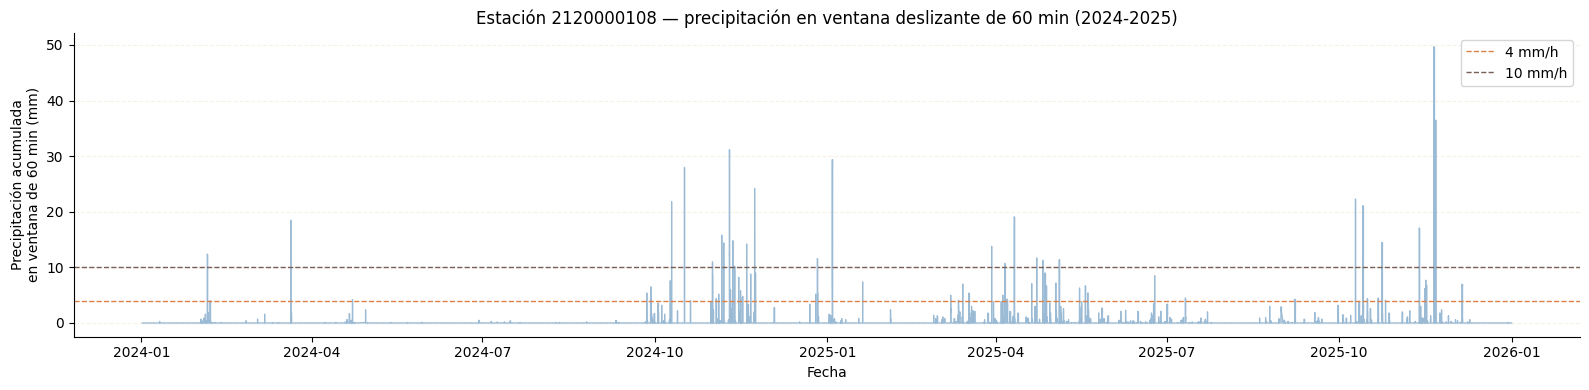

In [36]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(df_ventana_prueba['fechaobservacion'], df_ventana_prueba['precip_60min'],
        color='#94B6D2', linewidth=0.8, alpha=0.9)

ax.fill_between(df_ventana_prueba['fechaobservacion'], df_ventana_prueba['precip_60min'],
                alpha=0.3, color='#94B6D2')

# Líneas de umbral
for umbral, color, label in [(4, '#DD8047', '4 mm/h'), (10, '#775F55', '10 mm/h')]:
    ax.axhline(umbral, color=color, linestyle='--', linewidth=1, label=label)

ax.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
ax.set_axisbelow(True)
ax.set_xlabel('Fecha')
ax.set_ylabel('Precipitación acumulada\nen ventana de 60 min (mm)')
ax.set_title('Estación 2120000108 — precipitación en ventana deslizante de 60 min (2024-2025)', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

Registros con lluvia: 45,009

Distribución precip_60min (mm/h) — solo registros con lluvia:
count    45009.000000
mean         1.745051
std          3.816848
min          0.100000
50%          0.500000
75%          1.400000
90%          4.200000
95%          8.000000
99%         21.000000
max         49.700000
Name: precip_60min, dtype: float64


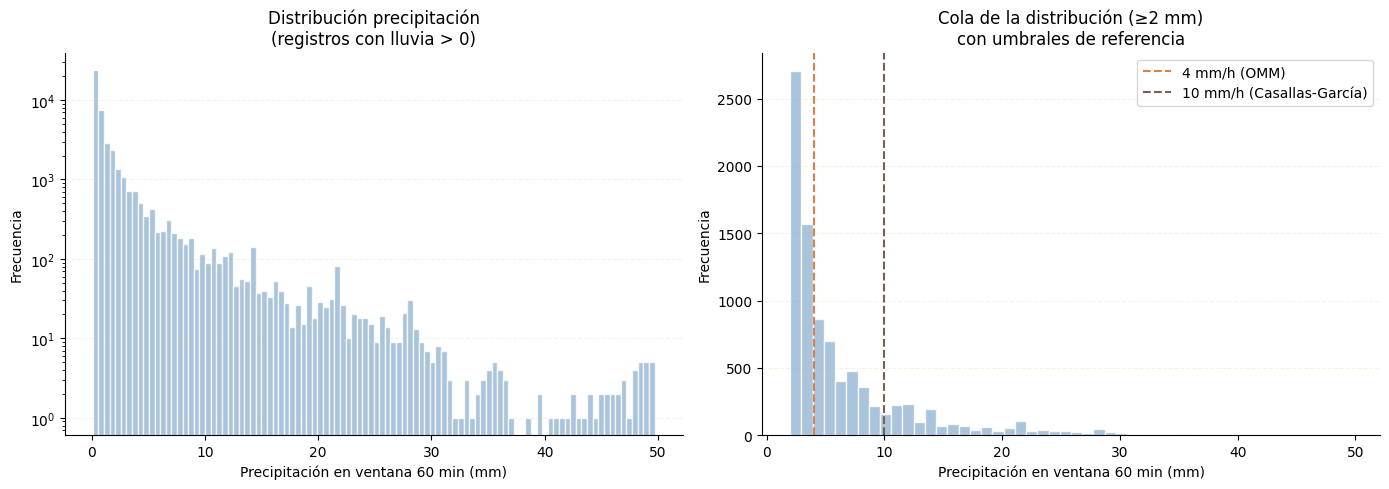

In [37]:
# Ventana deslizante para esta estación ya la tenemos en df_ventana_prueba
df_lluvia_prueba = df_ventana_prueba[df_ventana_prueba['precip_60min'] > 0].copy()

print(f"Registros con lluvia: {len(df_lluvia_prueba):,}")
print(f"\nDistribución precip_60min (mm/h) — solo registros con lluvia:")
print(df_lluvia_prueba['precip_60min'].describe(percentiles=[.5, .75, .90, .95, .99]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda — distribución completa en escala log
axes[0].hist(df_lluvia_prueba['precip_60min'], bins=100, color='#94B6D2', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Precipitación en ventana 60 min (mm)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución precipitación\n(registros con lluvia > 0)')
axes[0].set_yscale('log')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Derecha — cola con umbrales
df_cola_prueba = df_lluvia_prueba[df_lluvia_prueba['precip_60min'] >= 2]
axes[1].hist(df_cola_prueba['precip_60min'], bins=50, color='#94B6D2', alpha=0.8, edgecolor='white')
for umbral, label, color in [(4, '4 mm/h (OMM)', '#DD8047'),
                              (10, '10 mm/h (Casallas-García)', '#775F55')]:
    axes[1].axvline(umbral, color=color, linestyle='--', linewidth=1.5, label=label)
axes[1].set_xlabel('Precipitación en ventana 60 min (mm)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Cola de la distribución (≥2 mm)\ncon umbrales de referencia')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

for ax in axes:
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

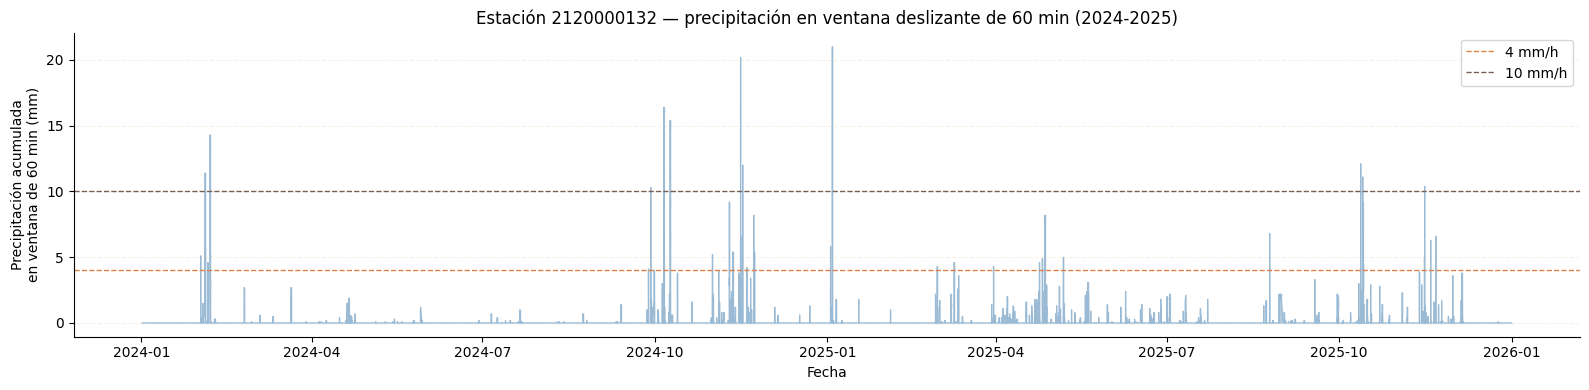

In [41]:
# Probar con una sola estación
df_prueba = df_precip[df_precip['codigoestacion'] == '2120000132'].copy()
df_prueba = df_prueba.sort_values('fechaobservacion').set_index('fechaobservacion')

df_ventana_prueba = (
    df_prueba['valorobservado']
    .rolling('60min', min_periods=1)
    .sum()
    .reset_index()
)
df_ventana_prueba.columns = ['fechaobservacion', 'precip_60min']

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(df_ventana_prueba['fechaobservacion'], df_ventana_prueba['precip_60min'],
        color='#94B6D2', linewidth=0.8, alpha=0.9)

ax.fill_between(df_ventana_prueba['fechaobservacion'], df_ventana_prueba['precip_60min'],
                alpha=0.3, color='#94B6D2')

# Líneas de umbral
for umbral, color, label in [(4, '#DD8047', '4 mm/h'), (10, '#775F55', '10 mm/h')]:
    ax.axhline(umbral, color=color, linestyle='--', linewidth=1, label=label)

ax.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
ax.set_axisbelow(True)
ax.set_xlabel('Fecha')
ax.set_ylabel('Precipitación acumulada\nen ventana de 60 min (mm)')
ax.set_title('Estación 2120000132 — precipitación en ventana deslizante de 60 min (2024-2025)', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

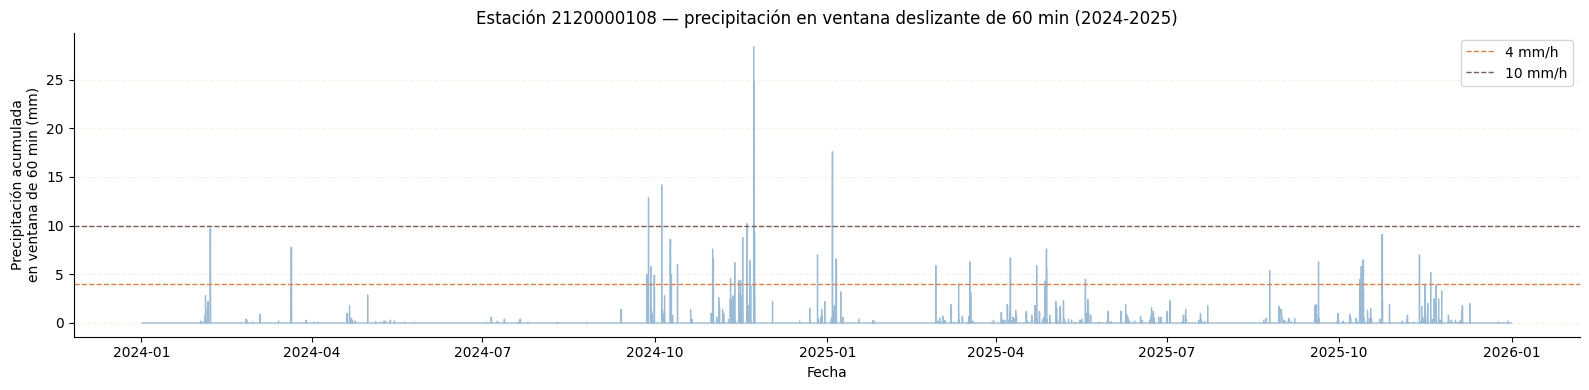

In [ ]:
# Ventana deslizante de 60 minutos
# Para cada registro, suma los mm en los 60 minutos anteriores

df_precip_sorted = df_precip.sort_values(['codigoestacion', 'fechaobservacion']).copy()

# Calcular precipitación acumulada en ventana deslizante de 60 min por estación
df_precip_sorted = df_precip_sorted.set_index('fechaobservacion')

df_ventana = (
    df_precip_sorted
    .groupby('codigoestacion')['valorobservado']
    .rolling('60min', min_periods=1)
    .sum()
    .reset_index()
)

df_ventana.columns = ['codigoestacion', 'fechaobservacion', 'precip_60min']

print(f"Total registros con ventana deslizante: {len(df_ventana):,}")
print(df_ventana.head(5))